# Time Series - Gaps and epochs

Real time series are rarely perfect. This tutorial builds a synthetic series with two kinds of gaps -- small scattered dropouts and larger block outages -- and walks through how `plans` represents, inspects, and fills them.

Covered here:

- Injecting realistic gaps into a synthetic series
- The `.gapsize` attribute and what counts as a "small" gap
- **Epochs**: continuous stretches of data separated by gaps too large to bridge
- Visualizing epochs with `.view_epochs()`
- Filling small gaps with `.interpolate_gaps()`, including the different interpolation methods and the `is_interpolation` flag column

Gap-filling only ever applies *within* an epoch -- bridging the gap *between* epochs is a different, harder problem (it usually needs an external predictor or reference series) and is out of scope here.

## Notebook setup

For users running this tutorial as a Jupyter Notebook, this cell must be executed first:

In [1]:
import sys
from pathlib import Path
import pprint
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Install `plans` in `google.colab`.
# Use `pip install plans` for other environments.

if "google.colab" in sys.modules:
    import os
    os.system(f"{sys.executable} -m pip install -q plans")

# This avoids warnings related to uninstalled fonts
import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# define output folder
OUTPUT_DIR = Path("outputs/time-series")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Outputs will be saved to: ./{OUTPUT_DIR}")

# fixed seed so the injected gaps are reproducible
RNG_SEED = 42
np.random.seed(RNG_SEED)

Outputs will be saved to: ./outputs\time-series


## Create a perfect synthetic series

Same starting point as the upscaling tutorial: a Trend-Seasonality-Noise archetype series.

In [2]:
from plans.datasets import TimeSeries

df_perfect = TimeSeries.make_synthetic_tsn(
    start="2020-01-01",
    end="2021-01-01",
    base=100,
    freq="1h",
    trend=0.001,
    noise_sd=4.0,
    amplitude=50,
    seasonal_period="YS",
    minor_amplitude=20,
    minor_seasonal_period="D"
)
print(f"Rows: {len(df_perfect)}")
df_perfect.head()

Rows: 8785


,datetime,level
0,2020-01-01 00:00:00,101.986857
1,2020-01-01 01:00:00,104.660089
2,2020-01-01 02:00:00,112.664284
3,2020-01-01 03:00:00,120.344550
4,2020-01-01 04:00:00,116.530954


## Inject gaps

Three kinds of imperfection, applied on a copy of the perfect data:

1. **Scattered small gaps** -- each row has an independent, small probability of being null. Mimics random sensor dropouts or bad readings. These are small enough to interpolate across.
2. **Two large block gaps** -- contiguous runs of nulls, long enough to represent real outages (e.g. equipment failure, maintenance). These are what split the record into separate **epochs**.

Two block gaps means the series ends up with **three epochs**: before the first outage, between the two outages, and after the second.

Scattered small gaps injected: 262 records
Block gap #1 injected: rows 4392 to 4632 (240 hours / 10 days)
Block gap #2 injected: rows 6588 to 6780 (192 hours / 8 days)

Total null records: 678 / 8785 (7.7%)


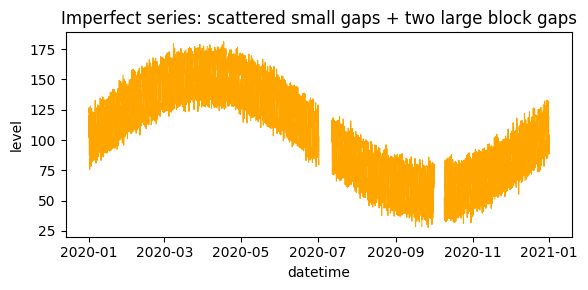

In [3]:
df_gappy = df_perfect.copy()
n = len(df_gappy)

# -- scattered small gaps (~3% of records, independently) --
SMALL_GAP_FRACTION = 0.03
mask_small = np.random.rand(n) < SMALL_GAP_FRACTION
df_gappy.loc[mask_small, "level"] = np.nan
print(f"Scattered small gaps injected: {mask_small.sum()} records")

# -- large block gap #1 (~10 days), placed near the middle --
BLOCK_1_HOURS = 24 * 10
block_1_start = n // 2
block_1_end = block_1_start + BLOCK_1_HOURS
df_gappy.loc[block_1_start:block_1_end, "level"] = np.nan
print(f"Block gap #1 injected: rows {block_1_start} to {block_1_end} "
      f"({BLOCK_1_HOURS} hours / {BLOCK_1_HOURS / 24:.0f} days)")

# -- large block gap #2 (~8 days), placed near the end --
BLOCK_2_HOURS = 24 * 8
block_2_start = 3 * n // 4
block_2_end = block_2_start + BLOCK_2_HOURS
df_gappy.loc[block_2_start:block_2_end, "level"] = np.nan
print(f"Block gap #2 injected: rows {block_2_start} to {block_2_end} "
      f"({BLOCK_2_HOURS} hours / {BLOCK_2_HOURS / 24:.0f} days)")

print(f"\nTotal null records: {df_gappy['level'].isna().sum()} / {n} "
      f"({100 * df_gappy['level'].isna().sum() / n:.1f}%)")

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(df_gappy["datetime"], df_gappy["level"], color="orange", linewidth=0.8)
ax.set_title("Imperfect series: scattered small gaps + two large block gaps")
ax.set_xlabel("datetime")
ax.set_ylabel("level")
plt.tight_layout()
plt.show()

## Save and load through the `TimeSeries` object

Same workflow as the upscaling tutorial: export to CSV, then load through `.load_data()`.

In [4]:
file_csv = OUTPUT_DIR / "time_series_gaps.csv"
df_gappy.to_csv(file_csv, sep=";", index=False)
print(f"Saved to: {file_csv}")

ts = TimeSeries(name="Gappy", alias="gap")
ts.load_data(
    file_data=file_csv,
    input_dtfield="datetime",
    input_varfield="level",
    in_sep=";",
)

Saved to: outputs\time-series\time_series_gaps.csv


## Inspect the imperfect data

The `.gapsize` attribute is the key threshold here: it defines, in number of consecutive missing records, how large a gap is allowed to be before it's treated as a hard break rather than something fillable. Any run of nulls **shorter** than `.gapsize` stays inside the same epoch (a "small gap"); any run **at or above** it breaks the series into a new epoch.

Total records: 8785
Null records:  678 (7.7%)
Detected native frequency (dtfreq): h
Gap-size tolerance attribute (.gapsize): 6


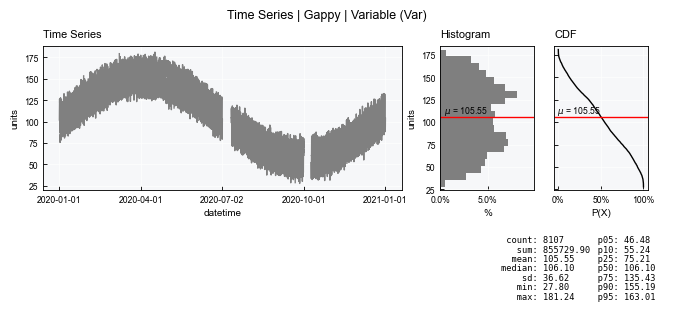

In [5]:
v = ts.varfield
n_total = len(ts.data)
n_null = ts.data[v].isna().sum()
print(f"Total records: {n_total}")
print(f"Null records:  {n_null} ({100 * n_null / n_total:.1f}%)")
print(f"Detected native frequency (dtfreq): {ts.dtfreq}")
print(f"Gap-size tolerance attribute (.gapsize): {ts.gapsize}")

ts.view_specs["n_dates"] = 5
ts.view()

## Epochs

An **epoch** is a continuous chunk of data where any internal gaps stay below the `.gapsize` tolerance -- only small, fillable gaps live inside an epoch. A gap at or above `.gapsize` records ends the current epoch and starts a new one; epoch `0` is reserved for the gap itself.

`.get_epochs()` computes this labeling and returns (or sets, with `inplace=True`) a DataFrame with the extra `id_epoch` column.

In [6]:
df_epochs = ts.get_epochs()
df_epochs.head(10)

,datetime,v,id_epoch
0,2020-01-01 00:00:00,101.986857,1
1,2020-01-01 01:00:00,104.660089,1
2,2020-01-01 02:00:00,112.664284,1
3,2020-01-01 03:00:00,120.344550,1
4,2020-01-01 04:00:00,116.530954,1
5,2020-01-01 05:00:00,118.565793,1
6,2020-01-01 06:00:00,126.537440,1
7,2020-01-01 07:00:00,122.645609,1
8,2020-01-01 08:00:00,NaN,1
9,2020-01-01 09:00:00,116.643258,1


`.update_epochs_stats()` summarizes each epoch: how many records it holds, how many small gaps it contains, and its start/end timestamps. The result is stored in `.epochs_stats`.

In [7]:
ts.update_epochs_stats()
ts.epochs_stats

,name,id_epoch,n_epoch,n_gaps_small,start,end,color
0,Gappy,1,4392,137,2020-01-01 00:00:00,2020-07-01 23:00:00,#1b9e77
1,Gappy,2,1955,54,2020-07-12 01:00:00,2020-10-01 11:00:00,#66a61e
2,Gappy,3,2003,53,2020-10-09 13:00:00,2020-12-31 23:00:00,#666666


`.view_epochs()` plots each epoch in its own color, with the gaps highlighted in red. With two block gaps injected, three epochs should be visible.

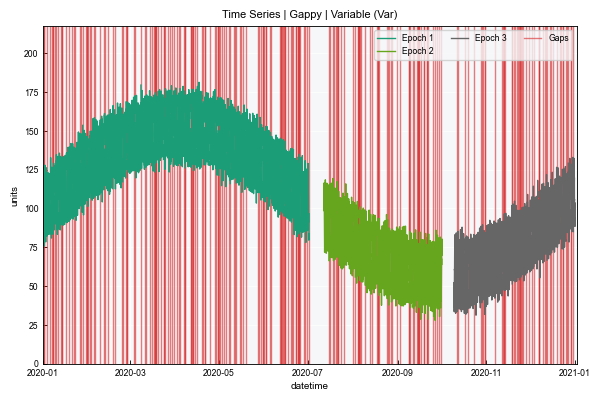

In [8]:
ts.view_epochs(show=True)

## Interpolate small gaps

`.interpolate_gaps()` fills the small gaps **within** each epoch. It never bridges the gap *between* epochs -- those records remain untouched (epoch `0` stays `NaN`).

Supported methods:

- ``linear``: linear interpolation
- ``nearest``: uses the value of the closest data point
- ``zero``: fills gaps with zeros
- ``constant``: fills gaps with a constant value provided via the `constant` parameter
- ``slinear``: first order spline interpolation
- ``quadratic``: second order spline interpolation
- ``cubic``: third order spline interpolation

**Caveat:** none of these methods prevent artifact values from occurring (e.g. negative values, or spline overshoot near sharp transitions) -- check your data range afterward.

With `inplace=False`, the returned DataFrame includes an `is_interpolation` flag column: `1` where the value was originally missing and got filled (or, for unfillable epoch-0 gaps, was missing and stayed `NaN`), `0` where the original value was already present. This makes it easy to later distinguish observed data from filled data downstream.

In [9]:
df_interpolation_linear = ts.interpolate_gaps(method="linear", inplace=False)
df_interpolation_linear.head(20)

,datetime,v,id_epoch,is_interpolation,v_interpolation
0,2020-01-01 00:00:00,101.986857,1,0,101.986857
1,2020-01-01 01:00:00,104.660089,1,0,104.660089
2,2020-01-01 02:00:00,112.664284,1,0,112.664284
3,2020-01-01 03:00:00,120.344550,1,0,120.344550
4,2020-01-01 04:00:00,116.530954,1,0,116.530954
5,2020-01-01 05:00:00,118.565793,1,0,118.565793
6,2020-01-01 06:00:00,126.537440,1,0,126.537440
7,2020-01-01 07:00:00,122.645609,1,0,122.645609
8,2020-01-01 08:00:00,NaN,1,1,119.644434
9,2020-01-01 09:00:00,116.643258,1,0,116.643258


Quick check: how many records were actually filled, versus how many stayed as unfillable gaps (epoch 0)?

In [10]:
n_filled = df_interpolation_linear["is_interpolation"].sum()
n_still_na = df_interpolation_linear[f"{v}_interpolation"].isna().sum()
print(f"Records flagged as interpolation: {n_filled}")
print(f"Records still NaN after interpolation (epoch-0 / between-epoch gaps): {n_still_na}")

Records flagged as interpolation: 678
Records still NaN after interpolation (epoch-0 / between-epoch gaps): 435


In [11]:
df_interpolation_nearest = ts.interpolate_gaps(method="nearest", inplace=False)
df_interpolation_nearest.head(20)

,datetime,v,id_epoch,is_interpolation,v_interpolation
0,2020-01-01 00:00:00,101.986857,1,0,101.986857
1,2020-01-01 01:00:00,104.660089,1,0,104.660089
2,2020-01-01 02:00:00,112.664284,1,0,112.664284
3,2020-01-01 03:00:00,120.344550,1,0,120.344550
4,2020-01-01 04:00:00,116.530954,1,0,116.530954
5,2020-01-01 05:00:00,118.565793,1,0,118.565793
6,2020-01-01 06:00:00,126.537440,1,0,126.537440
7,2020-01-01 07:00:00,122.645609,1,0,122.645609
8,2020-01-01 08:00:00,NaN,1,1,122.645609
9,2020-01-01 09:00:00,116.643258,1,0,116.643258


Testing with the `constant` approach -- useful for flagging filled values distinctly rather than blending them into the natural range of the data:

In [12]:
df_interpolation_constant = ts.interpolate_gaps(method="constant", constant=666, inplace=False)
df_interpolation_constant.head(20)

,datetime,v,id_epoch,is_interpolation,v_interpolation
0,2020-01-01 00:00:00,101.986857,1,0,101.986857
1,2020-01-01 01:00:00,104.660089,1,0,104.660089
2,2020-01-01 02:00:00,112.664284,1,0,112.664284
3,2020-01-01 03:00:00,120.344550,1,0,120.344550
4,2020-01-01 04:00:00,116.530954,1,0,116.530954
5,2020-01-01 05:00:00,118.565793,1,0,118.565793
6,2020-01-01 06:00:00,126.537440,1,0,126.537440
7,2020-01-01 07:00:00,122.645609,1,0,122.645609
8,2020-01-01 08:00:00,NaN,1,1,666.000000
9,2020-01-01 09:00:00,116.643258,1,0,116.643258


## Apply in place

`inplace=True` burns the interpolated values directly into `ts.data` (note: the `is_interpolation` flag itself is only returned in the `inplace=False` DataFrame -- it is not currently persisted onto the object).

In [13]:
ts.interpolate_gaps(method="linear", inplace=True)

Re-running the epoch analysis should now show zero small gaps per epoch -- only the between-epoch gaps remain:

In [14]:
ts.update_epochs_stats()
ts.epochs_stats

,name,id_epoch,n_epoch,n_gaps_small,start,end,color
0,Gappy,1,4392,0,2020-01-01 00:00:00,2020-07-01 23:00:00,#1b9e77
1,Gappy,2,1955,0,2020-07-12 01:00:00,2020-10-01 11:00:00,#66a61e
2,Gappy,3,2003,0,2020-10-09 13:00:00,2020-12-31 23:00:00,#666666


View epochs again -- there should be no red line marking small gaps:

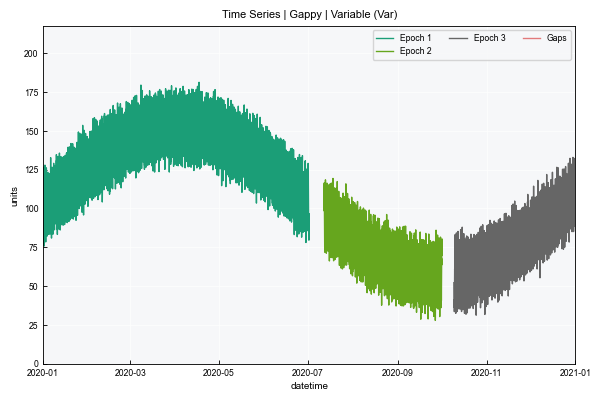

In [15]:
ts.view_epochs(show=True)

## Recap

- Gaps come in two flavors: small (fillable) and large (epoch-breaking), separated by the `.gapsize` threshold.
- `.get_epochs()` / `.update_epochs_stats()` / `.view_epochs()` let you inspect and visualize epoch structure before deciding how to handle gaps.
- `.interpolate_gaps()` fills only the small, within-epoch gaps; between-epoch gaps require a different strategy (e.g. an external predictor) and are out of scope here.
- The `is_interpolation` flag column (returned with `inplace=False`) lets you track which values are observed versus filled -- useful for downstream QA or for excluding filled values from certain analyses.
- This tutorial deliberately stopped before combining gap-filling with `.scale_up()` -- that pairing (clean first vs. tolerate via `bad_max`) is a natural next tutorial.